1. Phase 1: Business Understanding
The primary objective of this project is to analyze customer purchasing behavior to identify distinct segments. By understanding who the high-value customers are and who is at risk of leaving, the business can optimize marketing strategies and increase loyalty.

2. Phase 2: Data Understanding
In this phase, we load the Online Retail II dataset, which contains transactions for a UK-based non-store retail. We explore the features, data types, and identify quality issues such as missing values and cancellations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load the dataset
df_raw = pd.read_csv('/content/online_retail_II.csv')
df = df_raw.copy()

# Display basic info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   1

3. Phase 3: Data Preparation
Data preparation is the most critical step. We handle the quality issues identified: missing CustomerID, cancelled orders, and outliers. We also track the data volume to ensure transparency in our cleaning process.

In [4]:
# Record rows before cleaning
rows_before = df.shape[0]

# Cleaning: Remove missing Customer IDs and Cancellations
df.dropna(subset=['Customer ID'], inplace=True)
df = df[~df['Invoice'].astype(str).str.contains('C', na=False)]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Feature Engineering: Total Sales
df['TotalSum'] = df['Quantity'] * df['Price']

# Record rows after cleaning
rows_after = df.shape[0]
print(f"Rows before: {rows_before} | Rows after: {rows_after}")
print(f"Removed: {rows_before - rows_after} rows")

Rows before: 1067371 | Rows after: 805549
Removed: 261822 rows


3.1 RFM Feature Engineering
We transform the raw data into behavioral metrics: Recency (days since last purchase), Frequency (count of orders), and Monetary (total spend).

In [6]:
import datetime as dt

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalSum': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

4. Phase 4 & 5: Modeling and Evaluation
We apply K-Means Clustering, an unsupervised learning technique suitable for unlabeled retail data. We use the Elbow Method to find the optimal number of clusters and the Silhouette Score to evaluate the model.

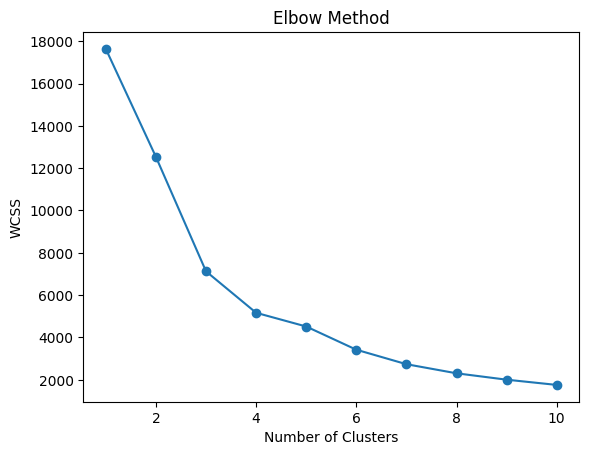

Silhouette Score: 0.59


In [7]:
# Scaling for K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Elbow Method to find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Final Model (Example: k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Evaluation
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score:.2f}")

5. Phase 6: Deployment & Insights
The final step involves interpreting the clusters to provide business recommendations.

In [9]:
import os

# Descriptive analysis of clusters
cluster_stats = rfm.groupby('Cluster').mean().round(1)
print(cluster_stats)

# Export for Dashboard
# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
rfm.to_csv('data/rfm_clusters.csv')

         Recency  Frequency  Monetary
Cluster                              
0          463.0        2.2     765.2
1           67.0        7.3    3009.4
2           25.9      103.7   83086.1
3            3.5      212.5  436835.8


Cluster Interpretation:

Cluster 0 (VIP): High Frequency and Monetary, Low Recency. Reward with loyalty points.  

Cluster 1 (At Risk): High Recency (haven't shopped in a long time). Target with discount coupons.  


Cluster 2 (New/Regular): Average spending and moderate activity.

### Phase 7: Bonus - Predictive Modeling
Now that we have labeled our customers into clusters, we will train a supervised learning model (Random Forest) to predict which segment a new customer will fall into based on their RFM metrics.

Classification Report for Customer Segment Prediction:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       399
           1       1.00      1.00      1.00       769
           2       0.71      0.83      0.77         6
           3       0.00      0.00      0.00         2

    accuracy                           1.00      1176
   macro avg       0.68      0.71      0.69      1176
weighted avg       1.00      1.00      1.00      1176



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


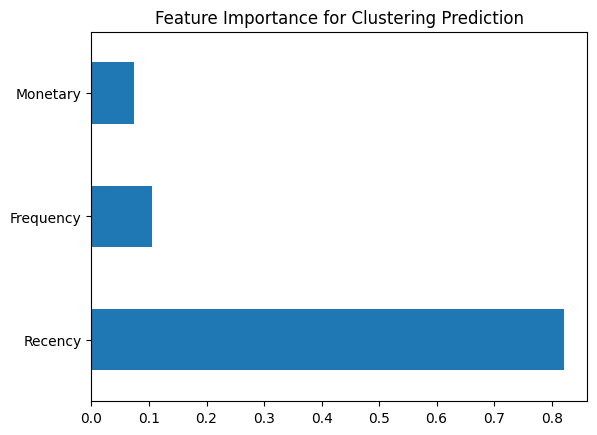

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define Features (X) and Target (y)
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Cluster']

# 2. Split Data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = clf.predict(X_test)

print("Classification Report for Customer Segment Prediction:")
print(classification_report(y_test, y_pred))

# 5. Visualize Feature Importance
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.plot(kind='barh', title='Feature Importance for Clustering Prediction')
plt.show()

In [13]:
rfm.to_csv('rfm_clusters.csv')